In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.decomposition import KernelPCA
from sklearn.metrics.pairwise import rbf_kernel

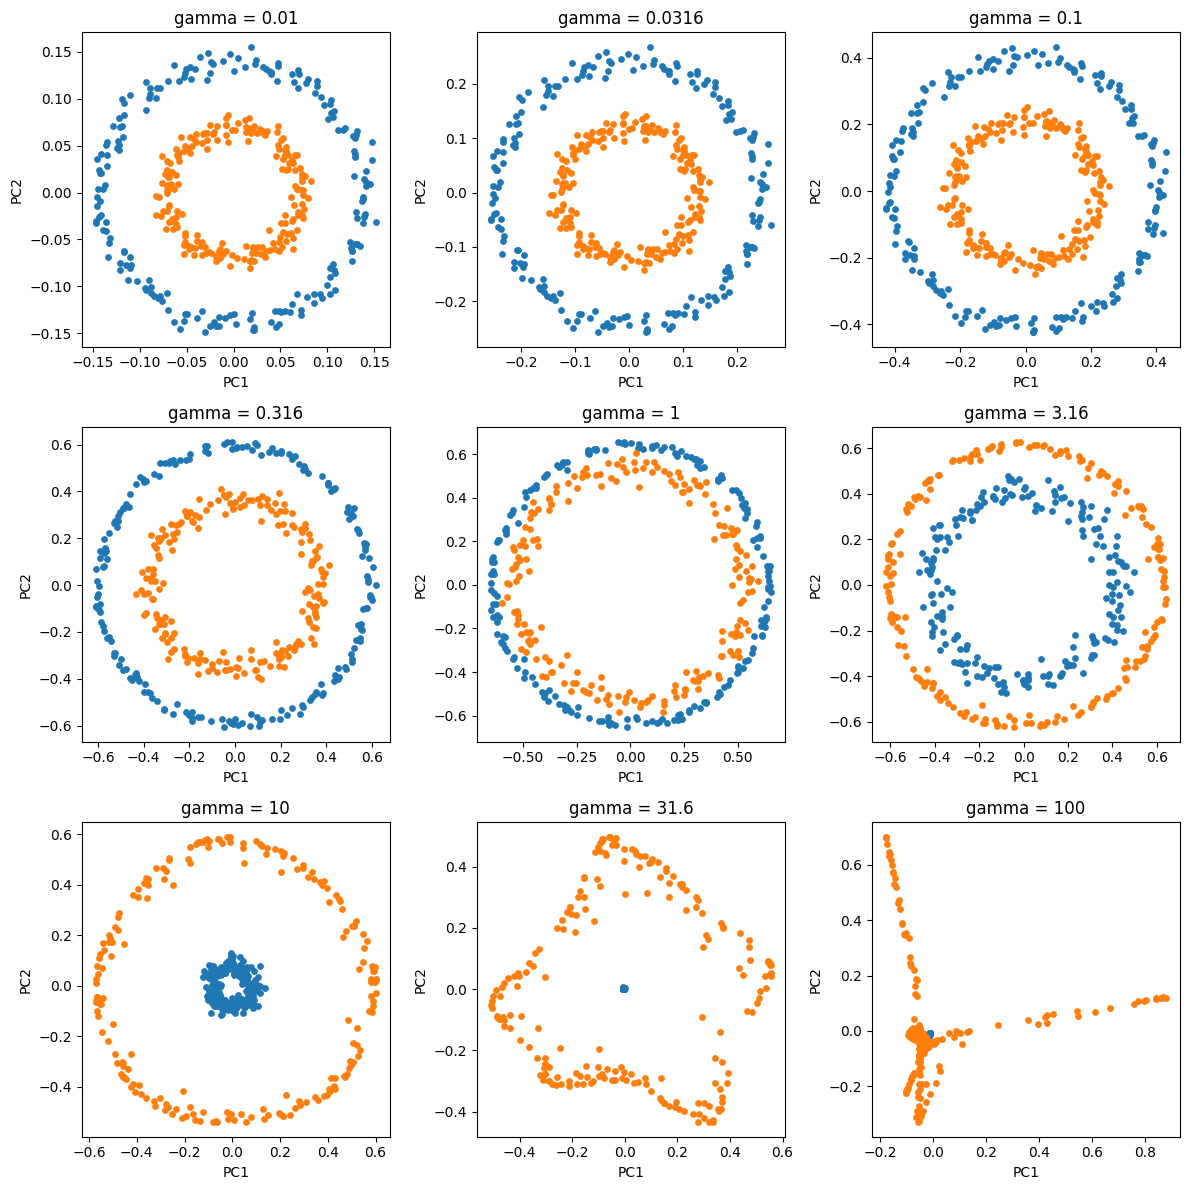

In [55]:
# 1. Generate one fixed dataset
X, y = make_circles(n_samples=400, factor=0.5, noise=0.05, random_state=0)

# 2. Gamma sweep across several orders of magnitude
gammas = np.logspace(-2, 2, 9)   # adjust later if needed

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.ravel()

for ax, gamma in zip(axes, gammas):
    kpca = KernelPCA(n_components=2, kernel='rbf', gamma=gamma)
    Z = kpca.fit_transform(X)

    ax.scatter(Z[y == 0, 0], Z[y == 0, 1], s=15, label='Outer')
    ax.scatter(Z[y == 1, 0], Z[y == 1, 1], s=15, label='Inner')
    ax.set_title(f"gamma = {gamma:.3g}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

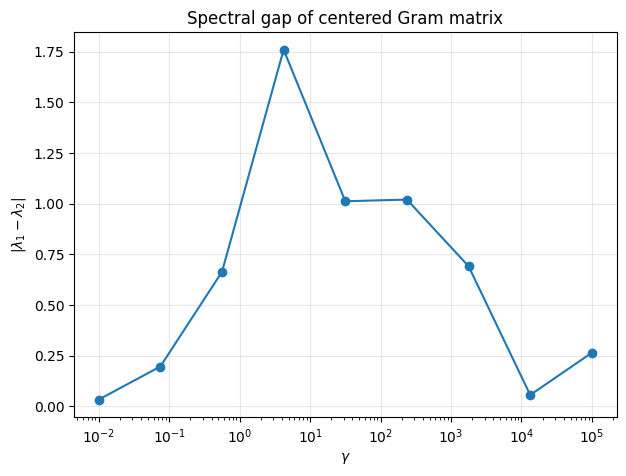

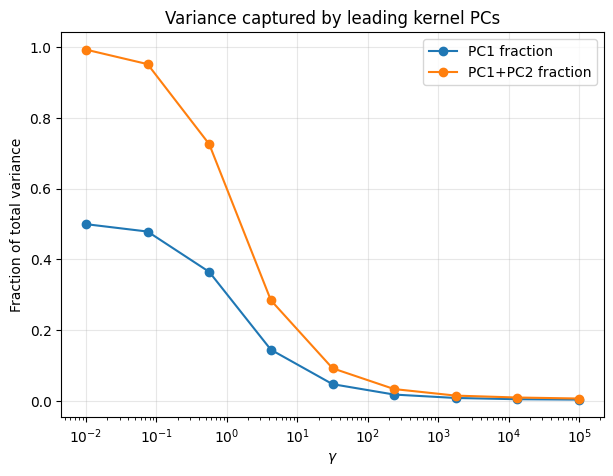

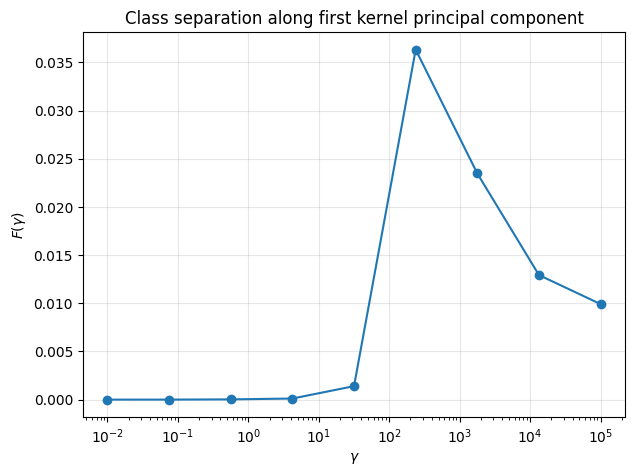

Best gamma for F(gamma): 237.137
Maximum F(gamma): 0.0363165


In [6]:

# class index sets
C1 = (y == 1)   # inner circle
C2 = (y == 0)   # outer circle

# important stuff
spectral_gap = []
var_frac_2d = []
var_frac_pc1 = []
F_scores = []
all_eigs = []

n = X.shape[0]
one_n = np.ones((n, n)) / n

for gamma in gammas:
    # uncentered Gram matrix
    K = rbf_kernel(X, X, gamma=gamma)

    # centered Gram matrix
    Kc = K - one_n @ K - K @ one_n + one_n @ K @ one_n

    # eigendecomposition of centered Gram matrix
    eigvals, eigvecs = np.linalg.eigh(Kc)

    # sort descending
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # numerical cleanup
    eigvals = np.maximum(eigvals, 0)

    all_eigs.append(eigvals)

    # (a) spectral gap |lambda1 - lambda2|
    gap = abs(eigvals[0] - eigvals[1])
    spectral_gap.append(gap)

    # (b) fraction of total variance captured by first 1 and 2 PCs
    total_var = eigvals.sum()
    if total_var > 0:
        var_frac_pc1.append(eigvals[0] / total_var)
        var_frac_2d.append((eigvals[0] + eigvals[1]) / total_var)
    else:
        var_frac_pc1.append(0.0)
        var_frac_2d.append(0.0)

    # (c) separation score along first kernel PC
    z = np.sqrt(eigvals[0]) * eigvecs[:, 0]

    mu1 = z[C1].mean()
    mu2 = z[C2].mean()

    s1_sq = ((z[C1] - mu1) ** 2).mean()
    s2_sq = ((z[C2] - mu2) ** 2).mean()

    F = (mu1 - mu2) ** 2 / (s1_sq + s2_sq)
    F_scores.append(F)

# convert to arrays
spectral_gap = np.array(spectral_gap)
var_frac_pc1 = np.array(var_frac_pc1)
var_frac_2d = np.array(var_frac_2d)
F_scores = np.array(F_scores)

# (a) Spectral gap plot
plt.figure(figsize=(7, 5))
plt.semilogx(gammas, spectral_gap, marker='o')
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$|\lambda_1 - \lambda_2|$')
plt.title('Spectral gap of centered Gram matrix')
plt.grid(True, alpha=0.3)
plt.show()

# (b) Variance fractions plot
plt.figure(figsize=(7, 5))
plt.semilogx(gammas, var_frac_pc1, marker='o', label='PC1 fraction')
plt.semilogx(gammas, var_frac_2d, marker='o', label='PC1+PC2 fraction')
plt.xlabel(r'$\gamma$')
plt.ylabel('Fraction of total variance')
plt.title('Variance captured by leading kernel PCs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# (c) Separation score plot
plt.figure(figsize=(7, 5))
plt.semilogx(gammas, F_scores, marker='o')
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$F(\gamma)$')
plt.title('Class separation along first kernel principal component')
plt.grid(True, alpha=0.3)
plt.show()

best_idx = np.argmax(F_scores)
print(f"Best gamma for F(gamma): {gammas[best_idx]:.6g}")
print(f"Maximum F(gamma): {F_scores[best_idx]:.6g}")

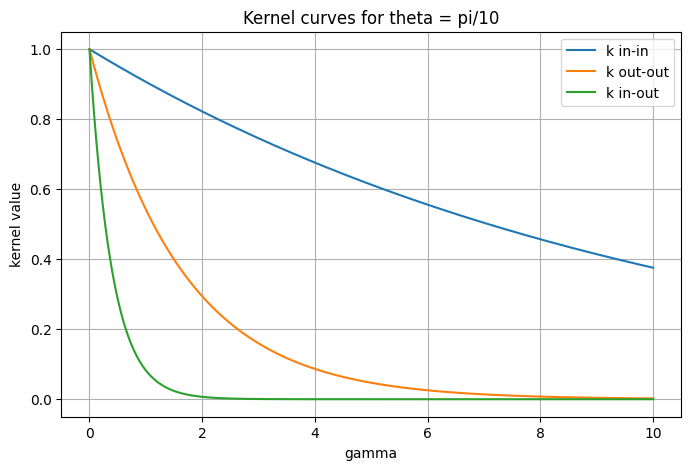

In [12]:
r1 = 1.0   # inner ring
r2 = 2.5   # outer ring

theta = np.pi / 10
gammas = np.linspace(0, 10, 500)

k_in_in = np.exp(-gammas * (2 * r1**2 * (1 - np.cos(theta))))
k_out_out = np.exp(-gammas * (2 * r2**2 * (1 - np.cos(theta))))
k_in_out = np.exp(-gammas * (r1**2 + r2**2 - 2 * r1 * r2 * np.cos(theta)))

plt.figure(figsize=(8, 5))
plt.plot(gammas, k_in_in, label="k in-in")
plt.plot(gammas, k_out_out, label="k out-out")
plt.plot(gammas, k_in_out, label="k in-out")

plt.xlabel("gamma")
plt.ylabel("kernel value")
plt.title("Kernel curves for theta = pi/10")
plt.legend()
plt.grid(True)
plt.show()

In [54]:
angles = [0, np.pi/2, np.pi, 3*np.pi/2]

# build the 8 points (4 inner, 4 outer)
X = []
labels = []
for a in angles:
    X.append([r1*np.cos(a), r1*np.sin(a)])
    labels.append("inner")
for a in angles:
    X.append([r2*np.cos(a), r2*np.sin(a)])
    labels.append("outer")
X = np.array(X)

gamma = 2

# compute Gram matrix
n = len(X)
K = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        d2 = np.sum((X[i] - X[j])**2)
        K[i, j] = np.exp(-gamma * d2)

print("K =\n", np.round(K, 3))

# check blocks
print("\nInner block K11:\n", np.round(K[:4, :4], 3))
print("\nOuter block K22:\n", np.round(K[4:, 4:], 3))
print("\nCross block:\n", np.round(K[:4, 4:], 3))

# --- Kernel PCA ---

# center K
one = np.ones((n, n)) / n
Kc = K - one @ K - K @ one + one @ K @ one

# eigendecomposition
eigvals, eigvecs = np.linalg.eigh(Kc)
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# embedding (top 2 components)
Y = eigvecs[:, :2] * np.sqrt(eigvals[:2])

print("avg inner:", np.mean(np.sqrt(np.sum(Y[4:]**2, axis=1))))
print("avg outer:", np.mean(np.sqrt(np.sum(Y[:4]**2, axis=1))))

K =
 [[1.    0.018 0.    0.018 0.011 0.    0.    0.   ]
 [0.018 1.    0.018 0.    0.    0.011 0.    0.   ]
 [0.    0.018 1.    0.018 0.    0.    0.011 0.   ]
 [0.018 0.    0.018 1.    0.    0.    0.    0.011]
 [0.011 0.    0.    0.    1.    0.    0.    0.   ]
 [0.    0.011 0.    0.    0.    1.    0.    0.   ]
 [0.    0.    0.011 0.    0.    0.    1.    0.   ]
 [0.    0.    0.    0.011 0.    0.    0.    1.   ]]

Inner block K11:
 [[1.    0.018 0.    0.018]
 [0.018 1.    0.018 0.   ]
 [0.    0.018 1.    0.018]
 [0.018 0.    0.018 1.   ]]

Outer block K22:
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

Cross block:
 [[0.011 0.    0.    0.   ]
 [0.    0.011 0.    0.   ]
 [0.    0.    0.011 0.   ]
 [0.    0.    0.    0.011]]
avg inner: 0.5065088107522143
avg outer: 0.49891892159532913
